# 🗳️ Linguistic Analysis of Political Discourse
## Phase 1: Data Exploration & Stylometric Foundations

This notebook serves as the initial exploration phase for the **Linguistic-analysis-** project. Our core mission is to quantify political rhetoric, specifically focusing on:

1.  **"Wooden Language" (*Langue de Bois*):** Identifying the ratio of abstract filler to concrete meaning.
2.  **The Populism of Simplicity:** Measuring linguistic complexity across temporal and political axes.

### NLP Objectives in this Notebook
- **Data Validation:** Ensure the integrity of the cleaned `archelect` dataset.
- **Metadata Profiling:** Analyze distributions of speaker backgrounds and political affiliations.
- **Textual Surface Analysis:** Initial inspection of `raw_text` properties.

This file is just used to visualize the data, nothing is important for the following.

### Setup & Environment
We initialize our environment and load the primary dataset.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("viridis")
DATA_PATH = "../data/clean/archelect_clean.parquet"
print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: /Users/gabriel/dev/python/ensae/Linguistic-analysis-/notebook


###  Data Loading

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"Dataset loaded with {df.shape[0]} documents and {df.shape[1]} features.")

Dataset loaded with 12746 documents and 16 features.


###  Structural Overview

In [3]:
display(df.info())
display(df.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 12746 entries, 0 to 12745
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         12746 non-null  str    
 1   raw_text                   12746 non-null  str    
 2   date                       12497 non-null  str    
 3   subject                    12497 non-null  str    
 4   title                      12497 non-null  str    
 5   contexte-election          12497 non-null  str    
 6   contexte-tour              12497 non-null  float64
 7   departement                12497 non-null  str    
 8   titulaire-nom              12497 non-null  str    
 9   titulaire-prenom           12497 non-null  str    
 10  titulaire-sexe             12497 non-null  str    
 11  titulaire-age              12497 non-null  str    
 12  titulaire-mandat-en-cours  12497 non-null  str    
 13  titulaire-mandat-passe     12497 non-null  str    
 14  t

None

,id,raw_text,date,subject,title,contexte-election,contexte-tour,departement,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-liste,affiliate political party
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",législatives,1.0,37,Mora,Christiane,femme,non mentionné,non mentionné,député sortant,Majorité présidentielle pour la France unie,PS
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,1988-06-05,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",législatives,1.0,78,Jonemann,Alain,homme,non mentionné,maire;conseiller général,conseiller régional,Union du rassemblement et du centre,RPR / LR
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",législatives,1.0,49,Bordier,François,homme,non mentionné,non mentionné,non mentionné,Majorité présidentielle pour la France unie,PS


### Unified Political Party Distribution

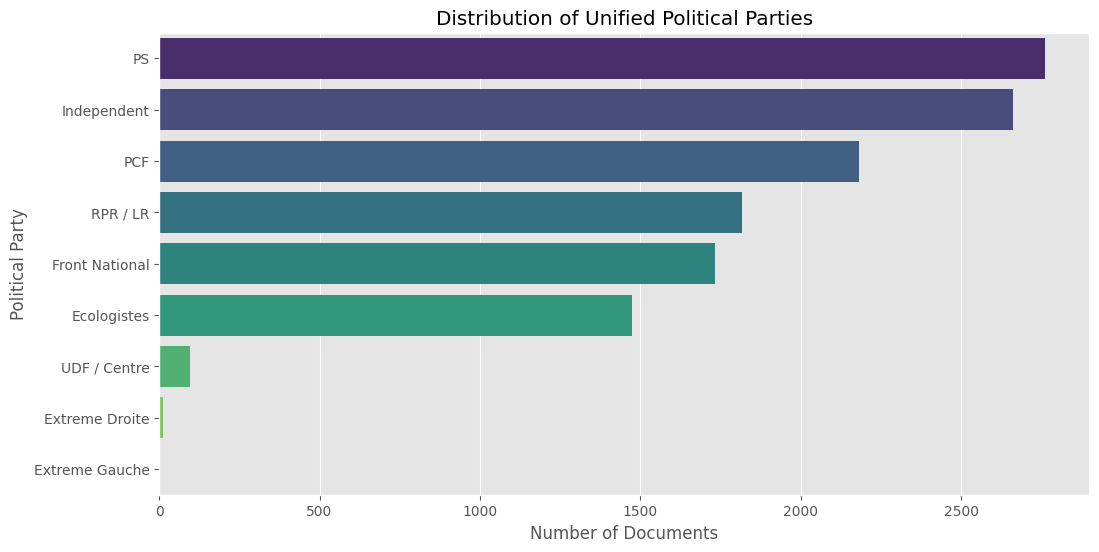

In [4]:
plt.figure(figsize=(12, 6))
party_counts = df["affiliate political party"].value_counts()
sns.barplot(
    x=party_counts.values,
    y=party_counts.index,
    hue=party_counts.index,
    palette="viridis",
    legend=False,
)
plt.title("Distribution of Unified Political Parties")
plt.xlabel("Number of Documents")
plt.ylabel("Political Party")
plt.show()

### ⏳ Temporal Dynamics & Political Presence

<Figure size 1400x700 with 0 Axes>

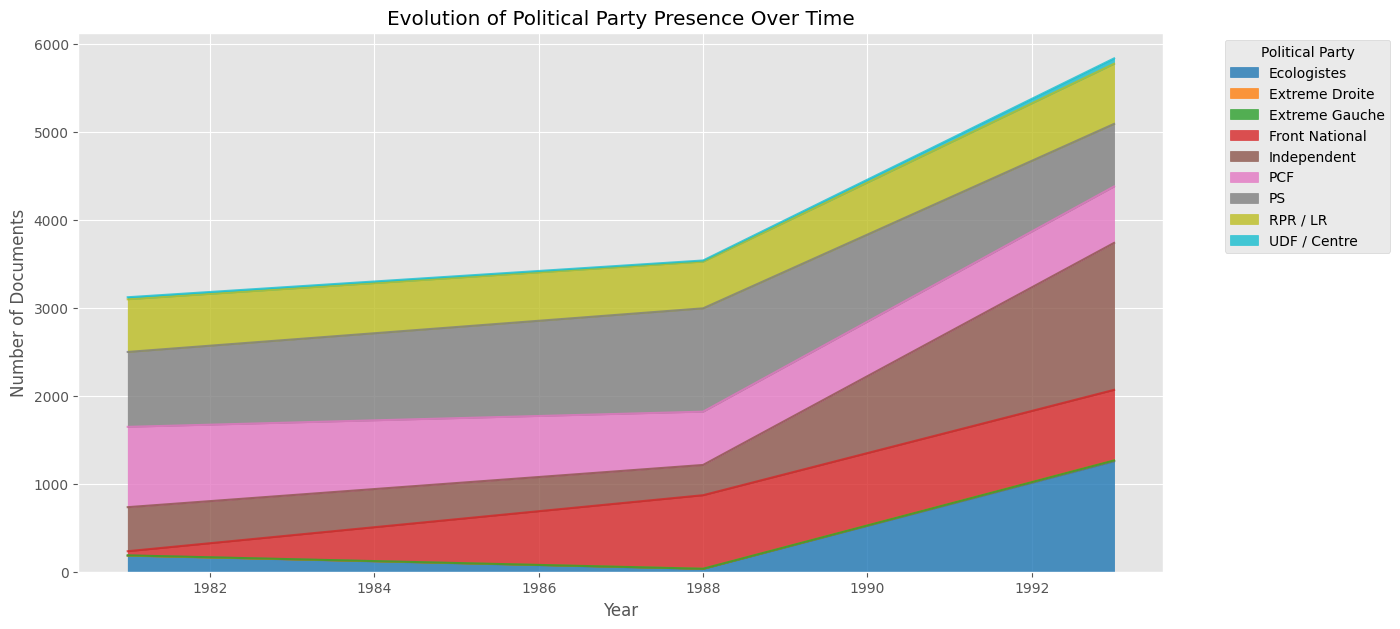

In [5]:
df["year"] = pd.to_datetime(df["date"]).dt.year
yearly_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(14, 7))
df_temporal = (
    df.groupby(["year", "affiliate political party"]).size().unstack(fill_value=0)
)
df_temporal.plot(
    kind="area", stacked=True, figsize=(14, 7), colormap="tab10", alpha=0.8
)
plt.title("Evolution of Political Party Presence Over Time")
plt.ylabel("Number of Documents")
plt.xlabel("Year")
plt.legend(title="Political Party", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### 📝 Textual Surface Analysis
Before deep NLP processing (PoS tagging, Readability formulas), we check the raw text properties.

Basic Text Statistics:


,char_count,word_count
count,12746.000000,12746.000000
mean,3929.173937,625.846462
std,2058.570716,331.266336
min,63.000000,9.000000
25%,2464.000000,391.000000
50%,3504.500000,557.000000
75%,5212.750000,830.000000
max,50611.000000,8255.000000


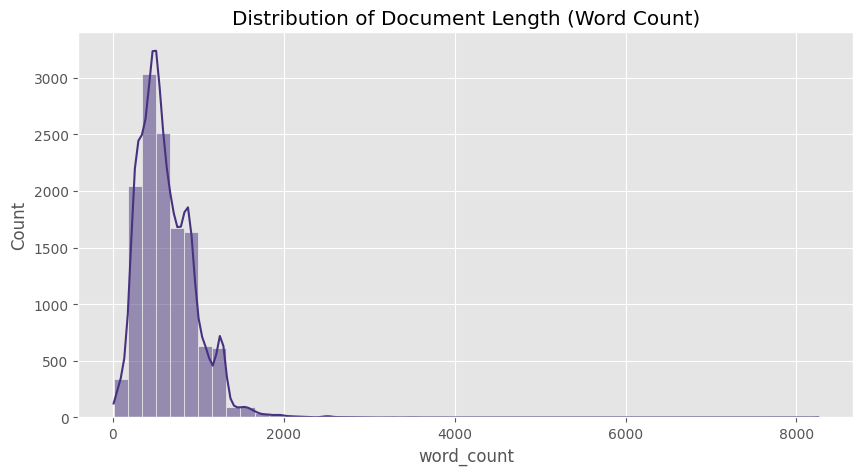

In [6]:
# Calculate basic document length metrics
df["char_count"] = df["raw_text"].str.len()
df["word_count"] = df["raw_text"].str.split().str.len()

print("Basic Text Statistics:")
display(df[["char_count", "word_count"]].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Distribution of Document Length (Word Count)")
plt.show()

### 🔬 Mission Sample Inspection
Let's look at a specific example of "Raw Text" to identify potential challenges for our "Wooden Language" metric (nominalizations, abstract fillers).

In [7]:
sample_text = df.iloc[0]["raw_text"]
print("--- Sample Text (First 500 characters) ---\n")
print(sample_text[:500] + "...")

--- Sample Text (First 500 characters) ---

Sciences Po / fonds CEVIPOF
LA FRANCE UNIE
AVEC
CHRISTIANE MORA
HENRI BOUSSIQUET SUPPLEANT
MAJORITE PRESIDENTIELLE POUR LA FRANCE UNIE ELECTIONS LEGISLATIVES DU 5 JUIN 1988
3º circonscription d'indre-et-loire
Madame, Mademoiselle, Monsieur,
Le 8 mai, avec 59,2 % des voix, les femmes et les hommes de notre circonscription ont largement renouvelé leur confiance au Président de la République François MITTERRAND. Cette victoire est celle d'une France rassemblée, plus juste et solidaire, une France o...
